In [1]:
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np

# Cargar dataset German Credit directamente desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columnas = [
    'estado_cuenta', 'duracion', 'historial_credito', 'proposito', 'monto_credito',
    'cuenta_ahorro', 'empleo', 'tasa_cuota', 'estado_personal', 'otros_deudores',
    'residencia', 'propiedad', 'edad', 'otros_planes', 'vivienda',
    'creditos_existentes', 'trabajo', 'personas_cargo', 'telefono',
    'trabajador_extranjero', 'clase'
]

df = pd.read_csv(url, sep=' ', header=None, names=columnas)

# Clase: 1=Buen cliente, 2=Mal cliente → convertir a 0 y 1
df['clase'] = df['clase'].map({1: 0, 2: 1})  # 0=No moroso, 1=Moroso

print("Shape del dataset:", df.shape)
print("\nDistribución de clases:")
print(df['clase'].value_counts())
df.head()

Shape del dataset: (1000, 21)

Distribución de clases:
clase
0    700
1    300
Name: count, dtype: int64


,estado_cuenta,duracion,historial_credito,proposito,monto_credito,cuenta_ahorro,empleo,tasa_cuota,estado_personal,otros_deudores,...,propiedad,edad,otros_planes,vivienda,creditos_existentes,trabajo,personas_cargo,telefono,trabajador_extranjero,clase
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
from sklearn.preprocessing import LabelEncoder

# Separar features y target
X = df.drop('clase', axis=1)
y = df['clase']

# Codificar variables categóricas (texto → número)
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

print("Variables después de codificar:")
print(X.dtypes)

Variables después de codificar:
estado_cuenta            int64
duracion                 int64
historial_credito        int64
proposito                int64
monto_credito            int64
cuenta_ahorro            int64
empleo                   int64
tasa_cuota               int64
estado_personal          int64
otros_deudores           int64
residencia               int64
propiedad                int64
edad                     int64
otros_planes             int64
vivienda                 int64
creditos_existentes      int64
trabajo                  int64
personas_cargo           int64
telefono                 int64
trabajador_extranjero    int64
dtype: object


In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# División 70% entrenamiento / 30% testing (ANTES de SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # mantiene proporción de clases
)

print("Antes de SMOTE:")
print("Entrenamiento:", X_train.shape, "| Distribución:", y_train.value_counts().to_dict())

# Aplicar SMOTE SOLO al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDespués de SMOTE:")
print("Entrenamiento:", X_train_smote.shape, "| Distribución:", y_train_smote.value_counts().to_dict())
print("Testing (sin tocar):", X_test.shape)

Antes de SMOTE:
Entrenamiento: (700, 20) | Distribución: {0: 490, 1: 210}

Después de SMOTE:
Entrenamiento: (980, 20) | Distribución: {1: 490, 0: 490}
Testing (sin tocar): (300, 20)


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 árboles
    max_depth=None,        # árboles sin límite de profundidad
    random_state=42,
    class_weight='balanced' # doble protección contra desbalance
)

rf_model.fit(X_train_smote, y_train_smote)
print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


       REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   No Moroso       0.82      0.86      0.84       210
      Moroso       0.62      0.56      0.59        90

    accuracy                           0.77       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.76      0.77      0.76       300

AUC-ROC: 0.7951


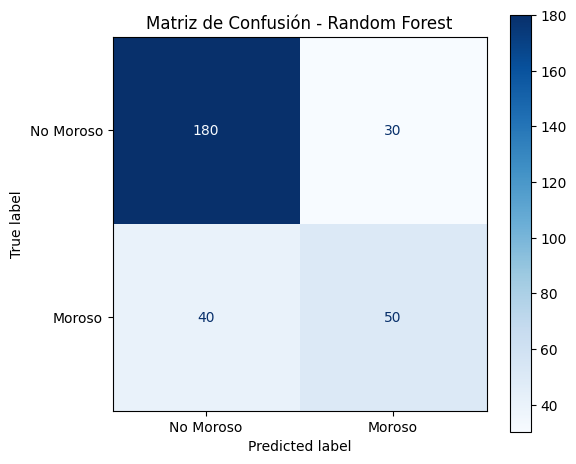

In [6]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Predicciones
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Reporte completo
print("="*50)
print("       REPORTE DE CLASIFICACIÓN")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Moroso', 'Moroso']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Moroso', 'Moroso'],
    cmap='Blues', ax=ax
)
plt.title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()

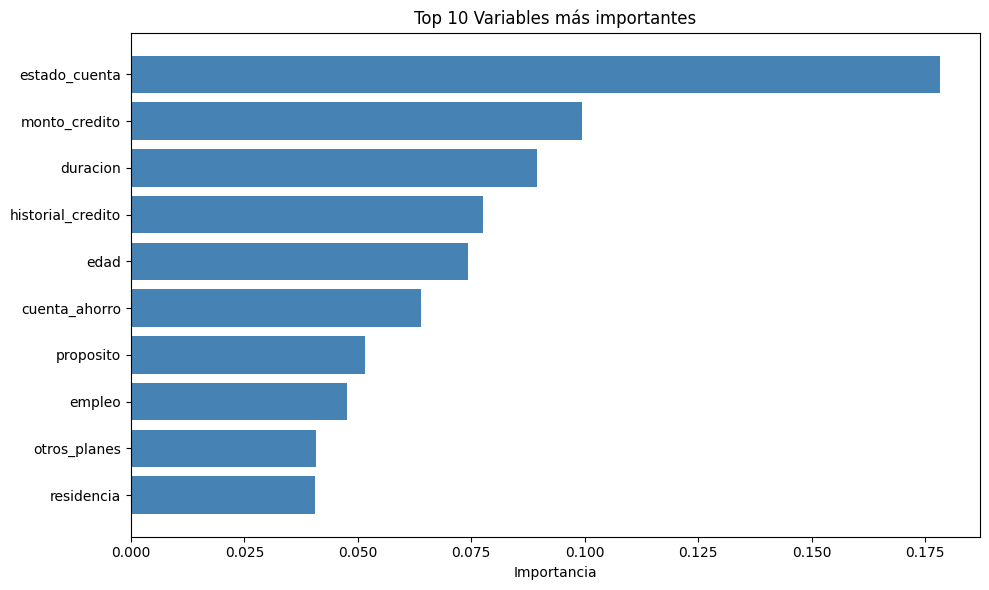

In [7]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importancias['Variable'][:10], importancias['Importancia'][:10], color='steelblue')
plt.xlabel("Importancia")
plt.title("Top 10 Variables más importantes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
import joblib

# Guardar modelo y columnas
joblib.dump(rf_model, 'modelo_crediticio.pkl')
joblib.dump(list(X.columns), 'columnas_modelo.pkl')

# Descargar desde Colab a tu PC
from google.colab import files
files.download('modelo_crediticio.pkl')
files.download('columnas_modelo.pkl')

print("✅ Archivos descargados. Guárdalos para la app web.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivos descargados. Guárdalos para la app web.
